## Visualize the 3 fidelities together

In [1]:
# ## Load and aggregate the three normalized metrics

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
FIDELITY_DIR = Path("/data/shared/fsibilla/clean_code/Q0/fidelity/zwe_mics")

MARGINAL_PATH = FIDELITY_DIR / "emd_gen_true_normalized.csv"
BIVARIATE_PATH = FIDELITY_DIR / "corrdiff_gen_true_normalized.csv"
JOINT_PATH = FIDELITY_DIR / "joint_emd_gen_true_normalized.csv"

marginal_df = pd.read_csv(MARGINAL_PATH)
bivariate_df = pd.read_csv(BIVARIATE_PATH)
joint_df = pd.read_csv(JOINT_PATH)

print("marginal_df:", marginal_df.shape)
print("bivariate_df:", bivariate_df.shape)
print("joint_df:", joint_df.shape)

display(marginal_df.head())
display(bivariate_df.head())
display(joint_df.head())

marginal_df: (591, 10)
bivariate_df: (591, 14)
joint_df: (197, 11)


,model,seed,adm1,variable,emd_distance,emd_ub,emd_lb,denom,emd_norm_raw,emd_norm
0,cNF,1,Bulawayo,space_per_person,0.251066,0.017924,0.200286,0.182362,1.278453e+00,1.000000
1,cNF,1,Bulawayo,avg_adult_education,5.791243,0.006368,0.122720,0.116353,4.971847e+01,1.000000
2,cNF,1,Bulawayo,wscore,0.472862,0.024156,1.069054,1.044898,4.294254e-01,0.429425
3,cNF,1,Harare,space_per_person,0.253198,0.004235,0.203703,0.199468,1.248131e+00,1.000000
4,cNF,1,Harare,avg_adult_education,221641.119766,0.009494,0.106224,0.096730,2.291346e+06,1.000000


,model,seed,adm1,var1,var2,pair,corr_real,corr_syn,corrdiff,corrdiff_ub,corrdiff_lb,denom,corrdiff_norm_raw,corrdiff_norm
0,cNF,1,Bulawayo,space_per_person,avg_adult_education,space_per_person__avg_adult_education,0.103404,0.048089,0.055315,0.008298,0.061937,0.053639,0.876540,0.876540
1,cNF,1,Bulawayo,space_per_person,wscore,space_per_person__wscore,0.175992,0.468999,0.293007,0.008019,0.170458,0.162439,1.754431,1.000000
2,cNF,1,Bulawayo,avg_adult_education,wscore,avg_adult_education__wscore,0.482778,0.091033,0.391745,0.017100,0.467739,0.450638,0.831364,0.831364
3,cNF,1,Harare,space_per_person,avg_adult_education,space_per_person__avg_adult_education,0.149286,0.046755,0.102531,0.015490,0.184193,0.168704,0.515942,0.515942
4,cNF,1,Harare,space_per_person,wscore,space_per_person__wscore,0.161277,0.467426,0.306149,0.007773,0.142569,0.134797,2.213529,1.000000


,model,seed,adm1,joint_emd,n_real,n_syn,emd_ub,emd_lb,denom,emd_norm_raw,emd_norm
0,cNF,1,Bulawayo,3.759714e+01,689,689,0.191504,1.600757,1.409253,2.654287e+01,1.0
1,cNF,1,Harare,1.551978e+06,1203,1203,0.157194,1.564621,1.407427,1.102706e+06,1.0
2,cNF,1,Manicaland,1.405810e+05,1141,1141,0.121756,0.672868,0.551112,2.550859e+05,1.0
3,cNF,1,Mashonaland Central,1.092757e+05,1088,1088,0.151592,0.943786,0.792195,1.379403e+05,1.0
4,cNF,1,Mashonaland East,5.968556e+03,1127,1127,0.135586,0.591482,0.455895,1.309165e+04,1.0


In [3]:
# Average marginal over variables for each (model, seed, adm1)
marginal_avg = (
    marginal_df
    .groupby(["model", "seed", "adm1"], as_index=False)
    .agg(
        marginal_norm=("emd_norm", "mean")
    )
)

# Average bivariate over pairs for each (model, seed, adm1)
bivariate_avg = (
    bivariate_df
    .groupby(["model", "seed", "adm1"], as_index=False)
    .agg(
        bivariate_norm=("corrdiff_norm", "mean")
    )
)

# Joint is already one value per (model, seed, adm1)
joint_avg = (
    joint_df[["model", "seed", "adm1", "emd_norm"]]
    .rename(columns={"emd_norm": "joint_norm"})
    .copy()
)

display(marginal_avg.head())
display(bivariate_avg.head())
display(joint_avg.head())

,model,seed,adm1,marginal_norm
0,CTGAN,1,Bulawayo,0.180932
1,CTGAN,1,Harare,0.272278
2,CTGAN,1,Manicaland,0.171893
3,CTGAN,1,Mashonaland Central,0.131128
4,CTGAN,1,Mashonaland East,0.126238


,model,seed,adm1,bivariate_norm
0,CTGAN,1,Bulawayo,0.458245
1,CTGAN,1,Harare,0.566376
2,CTGAN,1,Manicaland,0.107745
3,CTGAN,1,Mashonaland Central,0.138598
4,CTGAN,1,Mashonaland East,0.042772


,model,seed,adm1,joint_norm
0,cNF,1,Bulawayo,1.0
1,cNF,1,Harare,1.0
2,cNF,1,Manicaland,1.0
3,cNF,1,Mashonaland Central,1.0
4,cNF,1,Mashonaland East,1.0


In [4]:
# Merge the 3 metrics so each row is one (model, seed, adm1)
metrics_3way = (
    marginal_avg
    .merge(bivariate_avg, on=["model", "seed", "adm1"], how="inner")
    .merge(joint_avg, on=["model", "seed", "adm1"], how="inner")
    .copy()
)

print("metrics_3way shape:", metrics_3way.shape)
display(metrics_3way.head())

metrics_3way shape: (197, 6)


,model,seed,adm1,marginal_norm,bivariate_norm,joint_norm
0,CTGAN,1,Bulawayo,0.180932,0.458245,0.232221
1,CTGAN,1,Harare,0.272278,0.566376,0.341825
2,CTGAN,1,Manicaland,0.171893,0.107745,0.466464
3,CTGAN,1,Mashonaland Central,0.131128,0.138598,0.291471
4,CTGAN,1,Mashonaland East,0.126238,0.042772,0.405597


In [5]:
# Optional: save merged table
OUT_PATH = FIDELITY_DIR / "merged_marginal_bivariate_joint_normalized.csv"
metrics_3way.to_csv(OUT_PATH, index=False)
print(f"Saved merged table to: {OUT_PATH}")

Saved merged table to: /data/shared/fsibilla/clean_code/Q0/fidelity/zwe_mics/merged_marginal_bivariate_joint_normalized.csv


In [6]:
# ## Prepare radar-plot summary
#
# We want:
# - for each model and seed: average across adm1
# - then across seeds: mean
# - and std based on the adm1-level variability after seed averaging

METRIC_COLS = ["marginal_norm", "bivariate_norm", "joint_norm"]

# Mean over adm1 within each seed
seed_level = (
    metrics_3way
    .groupby(["model", "seed"], as_index=False)[METRIC_COLS]
    .mean()
)

display(seed_level.head())

,model,seed,marginal_norm,bivariate_norm,joint_norm
0,CTGAN,1,0.183085,0.247778,0.532186
1,CTGAN,2,0.199247,0.253202,0.511795
2,CTGAN,3,0.171698,0.280195,0.466456
3,CTGAN,4,0.201256,0.484324,0.585741
4,CTGAN,5,0.173786,0.300343,0.519355


In [7]:
# Mean and std across seeds for the central line
model_mean_std = (
    seed_level
    .groupby("model", as_index=False)
    .agg(
        marginal_mean=("marginal_norm", "mean"),
        marginal_std_seed=("marginal_norm", "std"),
        bivariate_mean=("bivariate_norm", "mean"),
        bivariate_std_seed=("bivariate_norm", "std"),
        joint_mean=("joint_norm", "mean"),
        joint_std_seed=("joint_norm", "std"),
    )
)

model_mean_std = model_mean_std.fillna(0.0)
display(model_mean_std)

,model,marginal_mean,marginal_std_seed,bivariate_mean,bivariate_std_seed,joint_mean,joint_std_seed
0,CTGAN,0.185815,0.013877,0.313168,0.098002,0.523107,0.042886
1,NF,0.885304,0.150594,0.688363,0.167252,1.000000,0.000000
2,TVAE,0.256508,0.081129,0.311165,0.077663,0.619519,0.098164
3,cNF,0.788437,0.305483,0.750196,0.170675,0.941615,0.130552


In [8]:
# Std over adm1:
# first average across seeds for each (model, adm1), then compute std across adm1

adm1_level = (
    metrics_3way
    .groupby(["model", "adm1"], as_index=False)[METRIC_COLS]
    .mean()
)

model_adm1_std = (
    adm1_level
    .groupby("model", as_index=False)
    .agg(
        marginal_std_adm1=("marginal_norm", "std"),
        bivariate_std_adm1=("bivariate_norm", "std"),
        joint_std_adm1=("joint_norm", "std"),
    )
)

model_adm1_std = model_adm1_std.fillna(0.0)
display(model_adm1_std)

,model,marginal_std_adm1,bivariate_std_adm1,joint_std_adm1
0,CTGAN,0.052160,0.125867,0.157852
1,NF,0.040835,0.074044,0.000000
2,TVAE,0.104259,0.088825,0.247327
3,cNF,0.032251,0.045281,0.049694


In [9]:
# Final table for plotting
radar_df = (
    model_mean_std
    .merge(model_adm1_std, on="model", how="left")
    .fillna(0.0)
)

display(radar_df)

,model,marginal_mean,marginal_std_seed,bivariate_mean,bivariate_std_seed,joint_mean,joint_std_seed,marginal_std_adm1,bivariate_std_adm1,joint_std_adm1
0,CTGAN,0.185815,0.013877,0.313168,0.098002,0.523107,0.042886,0.052160,0.125867,0.157852
1,NF,0.885304,0.150594,0.688363,0.167252,1.000000,0.000000,0.040835,0.074044,0.000000
2,TVAE,0.256508,0.081129,0.311165,0.077663,0.619519,0.098164,0.104259,0.088825,0.247327
3,cNF,0.788437,0.305483,0.750196,0.170675,0.941615,0.130552,0.032251,0.045281,0.049694


In [10]:
# ## Spider / radar plot

MODEL_ORDER = ["cNF", #"NF", 
"TVAE", "CTGAN"]
MODEL_ORDER = [m for m in MODEL_ORDER if m in radar_df["model"].unique()]

MODEL_COLORS = {
    "cNF": "tab:blue",
    "NF": "tab:orange",
    "TVAE": "tab:green",
    "CTGAN": "tab:red",
}

AXES_LABELS = ["Marginal", "Bivariate", "Joint"]
N_AXES = len(AXES_LABELS)

angles = np.linspace(0, 2 * np.pi, N_AXES, endpoint=False).tolist()
angles += angles[:1]  # close polygon

In [11]:
def close_vals(vals):
    vals = list(vals)
    return vals + vals[:1]

In [12]:
# Convert normalized errors into normalized fidelity scores
radar_score_df = radar_df.copy()

for col in [
    "marginal_mean", "bivariate_mean", "joint_mean",
]:
    radar_score_df[col] = 1.0 - radar_score_df[col]

display(radar_score_df)

,model,marginal_mean,marginal_std_seed,bivariate_mean,bivariate_std_seed,joint_mean,joint_std_seed,marginal_std_adm1,bivariate_std_adm1,joint_std_adm1
0,CTGAN,0.814185,0.013877,0.686832,0.098002,0.476893,0.042886,0.052160,0.125867,0.157852
1,NF,0.114696,0.150594,0.311637,0.167252,0.000000,0.000000,0.040835,0.074044,0.000000
2,TVAE,0.743492,0.081129,0.688835,0.077663,0.380481,0.098164,0.104259,0.088825,0.247327
3,cNF,0.211563,0.305483,0.249804,0.170675,0.058385,0.130552,0.032251,0.045281,0.049694


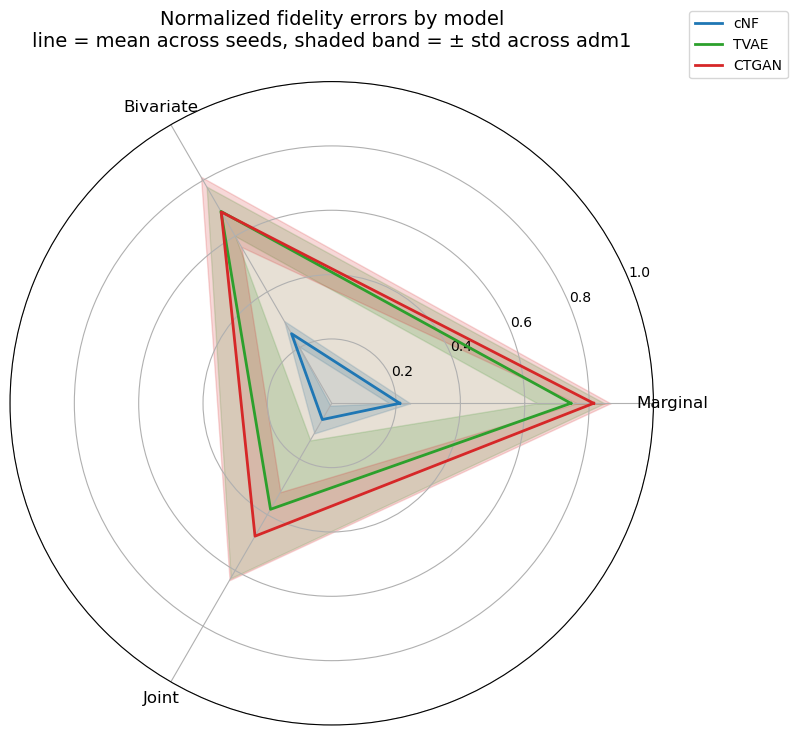

In [13]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for model in MODEL_ORDER:
    row = radar_score_df.loc[radar_score_df["model"] == model]
    if row.empty:
        continue
    row = row.iloc[0]

    means = [
        row["marginal_mean"],
        row["bivariate_mean"],
        row["joint_mean"],
    ]

    stds_adm1 = [
        row["marginal_std_adm1"],
        row["bivariate_std_adm1"],
        row["joint_std_adm1"],
    ]

    lower = np.clip(np.array(means) - np.array(stds_adm1), 0, 1)
    upper = np.clip(np.array(means) + np.array(stds_adm1), 0, 1)

    means_c = close_vals(means)
    lower_c = close_vals(lower)
    upper_c = close_vals(upper)

    color = MODEL_COLORS.get(model, "gray")

    ax.plot(
        angles,
        means_c,
        color=color,
        linewidth=2,
        label=model,
    )

    ax.fill(
        angles,
        means_c,
        color=color,
        alpha=0.10,
    )

    ax.fill_between(
        angles,
        lower_c,
        upper_c,
        color=color,
        alpha=0.18,
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(AXES_LABELS, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"])
ax.set_title(
    "Normalized fidelity errors by model\nline = mean across seeds, shaded band = ± std across adm1",
    pad=25,
    fontsize=14
)
ax.legend(loc="upper right", bbox_to_anchor=(1.22, 1.12))

plt.tight_layout()
plt.show()

## Look at originality too

In [14]:
# ## Load fidelity + recall

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
FIDELITY_DIR = Path("/data/shared/fsibilla/clean_code/Q0/fidelity/zwe_mics")
RECALL_DIR = Path("/data/shared/fsibilla/clean_code/Q0/recall/zwe_mics")

FIDELITY_3WAY_PATH = FIDELITY_DIR / "merged_marginal_bivariate_joint_normalized.csv"
RECALL_PATH = RECALL_DIR / "recall_gen_true_by_adm1.csv"

fidelity_3way = pd.read_csv(FIDELITY_3WAY_PATH)
recall_df = pd.read_csv(RECALL_PATH)

print("fidelity_3way:", fidelity_3way.shape)
print("recall_df:", recall_df.shape)

display(fidelity_3way.head())
display(recall_df.head())

fidelity_3way: (197, 6)
recall_df: (197, 8)


,model,seed,adm1,marginal_norm,bivariate_norm,joint_norm
0,CTGAN,1,Bulawayo,0.180932,0.458245,0.232221
1,CTGAN,1,Harare,0.272278,0.566376,0.341825
2,CTGAN,1,Manicaland,0.171893,0.107745,0.466464
3,CTGAN,1,Mashonaland Central,0.131128,0.138598,0.291471
4,CTGAN,1,Mashonaland East,0.126238,0.042772,0.405597


,model,seed,adm1,recall,matched_real,n_real,n_syn,radius
0,cNF,1,Bulawayo,0.943396,650,689,689,0.5
1,cNF,1,Harare,0.972569,1170,1203,1203,0.5
2,cNF,1,Manicaland,0.937774,1070,1141,1141,0.5
3,cNF,1,Mashonaland Central,0.917279,998,1088,1088,0.5
4,cNF,1,Mashonaland East,0.937888,1057,1127,1127,0.5


In [16]:
# Average the 3 fidelity metrics into one fidelity score (still an error, so lower is better)
fidelity_3way = fidelity_3way.copy()

fidelity_3way["fidelity_mean"] = fidelity_3way[
    ["marginal_norm", "bivariate_norm", "joint_norm"]
].mean(axis=1)

display(fidelity_3way.head())

,model,seed,adm1,marginal_norm,bivariate_norm,joint_norm,fidelity_mean
0,CTGAN,1,Bulawayo,0.180932,0.458245,0.232221,0.290466
1,CTGAN,1,Harare,0.272278,0.566376,0.341825,0.393493
2,CTGAN,1,Manicaland,0.171893,0.107745,0.466464,0.248701
3,CTGAN,1,Mashonaland Central,0.131128,0.138598,0.291471,0.187066
4,CTGAN,1,Mashonaland East,0.126238,0.042772,0.405597,0.191536


In [17]:
# Keep only the columns needed for the merge
fidelity_for_merge = fidelity_3way[
    ["model", "seed", "adm1", "fidelity_mean"]
].copy()

recall_for_merge = recall_df[
    ["model", "seed", "adm1", "recall"]
].copy()

plot_source = (
    fidelity_for_merge
    .merge(recall_for_merge, on=["model", "seed", "adm1"], how="inner")
    .copy()
)

print("plot_source shape:", plot_source.shape)
display(plot_source.head())

plot_source shape: (197, 5)


,model,seed,adm1,fidelity_mean,recall
0,CTGAN,1,Bulawayo,0.290466,0.970972
1,CTGAN,1,Harare,0.393493,0.960100
2,CTGAN,1,Manicaland,0.248701,0.958808
3,CTGAN,1,Mashonaland Central,0.187066,0.944853
4,CTGAN,1,Mashonaland East,0.191536,0.964508


In [18]:
# One scatter point per model with x/y std dev error bars
model_summary = (
    plot_source
    .groupby("model", as_index=False)
    .agg(
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        fidelity_mean=("fidelity_mean", "mean"),
        fidelity_std=("fidelity_mean", "std"),
        n_rows=("recall", "count"),
    )
)

model_summary["recall_std"] = model_summary["recall_std"].fillna(0.0)
model_summary["fidelity_std"] = model_summary["fidelity_std"].fillna(0.0)

display(model_summary)

,model,recall_mean,recall_std,fidelity_mean,fidelity_std,n_rows
0,CTGAN,0.955158,0.013243,0.340697,0.095365,50
1,NF,0.758853,0.275070,0.857889,0.087408,50
2,TVAE,0.926263,0.125244,0.394311,0.154920,47
3,cNF,0.828418,0.123164,0.826749,0.171030,50


In [19]:
MODEL_ORDER = ["cNF", #"NF",
 "TVAE", "CTGAN"]
MODEL_ORDER = [m for m in MODEL_ORDER if m in model_summary["model"].unique()]

MODEL_COLORS = {
    "cNF": "tab:blue",
    #"NF": "tab:orange",
    "TVAE": "tab:green",
    "CTGAN": "tab:red",
}

model_summary = (
    model_summary
    .set_index("model")
    .loc[MODEL_ORDER]
    .reset_index()
)

display(model_summary)

,model,recall_mean,recall_std,fidelity_mean,fidelity_std,n_rows
0,cNF,0.828418,0.123164,0.826749,0.171030,50
1,TVAE,0.926263,0.125244,0.394311,0.154920,47
2,CTGAN,0.955158,0.013243,0.340697,0.095365,50


In [20]:
model_summary_plot = model_summary.copy()
model_summary_plot["fidelity_score"] = 1.0 - model_summary_plot["fidelity_mean"]

display(model_summary_plot)

,model,recall_mean,recall_std,fidelity_mean,fidelity_std,n_rows,fidelity_score
0,cNF,0.828418,0.123164,0.826749,0.171030,50,0.173251
1,TVAE,0.926263,0.125244,0.394311,0.154920,47,0.605689
2,CTGAN,0.955158,0.013243,0.340697,0.095365,50,0.659303


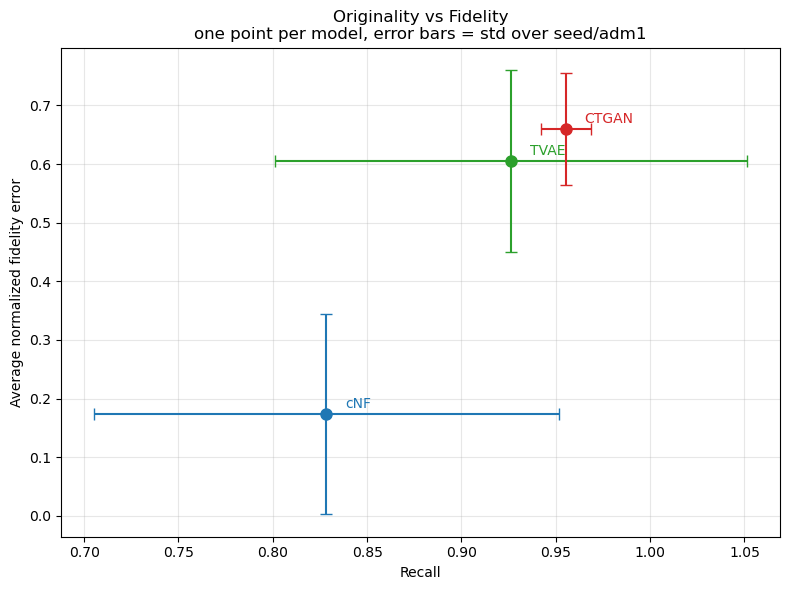

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))

for _, row in model_summary_plot.iterrows():
    model = row["model"]
    x = row["recall_mean"]
    y = row["fidelity_score"]
    xerr = row["recall_std"]
    yerr = row["fidelity_std"]
    color = MODEL_COLORS.get(model, "gray")

    ax.errorbar(
        x,
        y,
        xerr=xerr,
        yerr=yerr,
        fmt="o",
        capsize=4,
        markersize=8,
        color=color,
        ecolor=color,
        elinewidth=1.5,
        label=model,
    )

    ax.text(
        x + 0.01,
        y + 0.01,
        model,
        fontsize=10,
        color=color,
    )

ax.set_xlabel("Recall")
ax.set_ylabel("Average normalized fidelity error")
ax.set_title("Originality vs Fidelity\none point per model, error bars = std over seed/adm1")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()